In [9]:
import pickle

import feyn
import numpy as np
import pandas as pd
import torch
from autora.theorist.bms import BMSRegressor
from feyn import Model
from gplearn.functions import make_function
from gplearn.genetic import SymbolicRegressor
from kan import KAN, create_dataset
from kan.utils import add_symbolic
from matplotlib import font_manager
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


# Comparison of Symbolic Regression using Kolmogorov-Arnold Networks (KANs), Genetic Programming methods and Bayes-based methods

In this notebook, we will compare three **symbolic regression** techniques for learning this **multivariate** mathematical function:

$$
y = sin(x_1^2) + e^{\frac{x_2}{4}} + 1
$$

1. **Kolmogorov-Arnold-Networks (KAN)**: We will train a KAN using the official **PyKAN** library, to perform symbolic regression.

2. **Genetic Programming**: We will use the **gplearn** library, which implements genetic programming, to find a symbolic representation of the function using evolutionary techniques.
   
3. **Bayesian Symbolic Regression (BSR)**: We will use the [autora](https://pypi.org/project/autora/) library to solve the symbolic regression task using the Bayesian approach.

4. **QLattice**: QLattice is the winner of the Synthetic Track of the [SRBench Competition 2022](https://cavalab.org/srbench/competition-2022/).

## Dataset definition and plotting

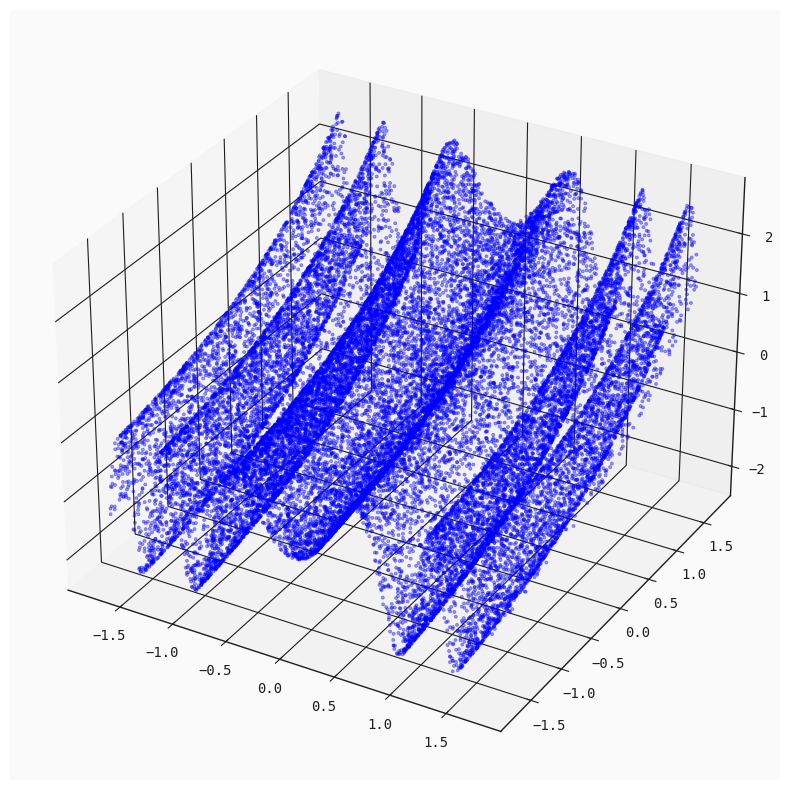

In [2]:
sin_exp = lambda x: torch.sin(x[:, 0] ** 2) + torch.exp(x[:, 1] / 4) + 1
noise_std = .05
dataset = create_dataset(sin_exp, n_var=2, ranges=[-4, 4], train_num=30000, test_num=5000,
                         normalize_input=True, normalize_label=True)
# dataset['train_label'] += np.random.normal(0, noise_std, (1000, ))
Xs, Ys = dataset['train_input'], dataset['train_label']

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))
ax.scatter(Xs[:, 0], Xs[:, 1], Ys[:, 0], c='blue', marker='.', alpha=0.4, linewidths=.5)
plt.show()

## 1. Using a KAN

In [ ]:
# kan_model = KAN.loadckpt('model/multivariate_kan_model')
# kan_model.plot()

In [3]:
kan_model = KAN(width=[2, 2, 1], grid=4, k=3)
pass

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.84e-02 | test_loss: 2.83e-02 | reg: 1.37e+01 | : 100%|█| 50/50 [01:07<00:00,  1.35s/


saving model version 0.1


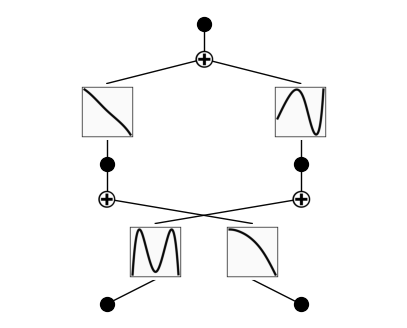

In [4]:
kan_model.fit(dataset, opt='LBFGS', steps=50, lamb=0.001, lamb_entropy=4)
kan_model.plot()
# kan_model.saveckpt('model/multivariate_kan_model')

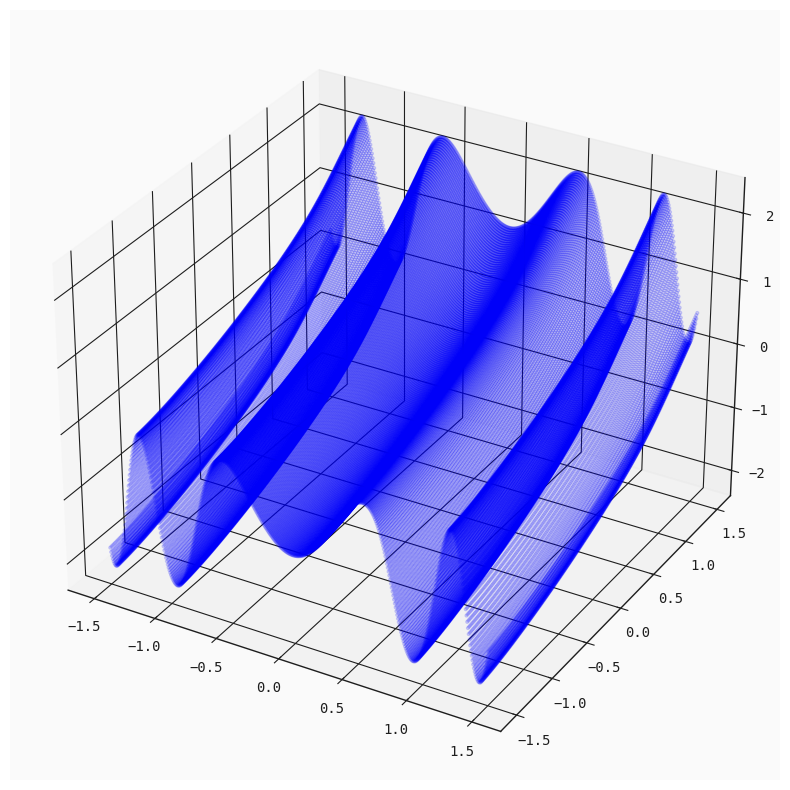

In [5]:
Xs2 = torch.cartesian_prod(torch.linspace(-1.5, 1.5, 500), torch.linspace(-1.5, 1.5, 200))
with torch.no_grad():
    Ys2 = kan_model(Xs2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xs2[:, 0], Xs2[:, 1], Ys2[:, 0], c='blue', marker='.', alpha=0.15, linewidths=0.75)
plt.show()

## 2. Using a Gplearn

In [18]:
# with open("multivariate_gplearn_model.pkl", "rb") as f:
#     genetic_model: SymbolicRegressor = pickle.load(f)

In [14]:
def _exponent(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        a = np.exp(x)
        a[np.greater(a, 10)] = 10
        a[np.less(a, 1 / 10.)] = 1 / 10.
        return a


exp = make_function(function=_exponent, name='exp', arity=1)
genetic_model = SymbolicRegressor(
    population_size=20000,
    generations=5,
    init_depth=(4, 10),
    metric='mse',
    function_set=('add', 'mul', 'sin', exp),
    n_jobs=-1,
    verbose=1,
)

In [15]:
genetic_model.fit(Xs, Ys)
# with open("multivariate_gplearn_model.pkl", "wb") as f:
#     pickle.dump(genetic_model, f)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    47.01      4.38968e+22        3         0.520031              N/A     56.27s
   1    18.45          40.8025       21         0.512798              N/A     41.84s
   2     4.38         0.928488       21         0.512798              N/A     29.66s
   3     3.67         0.820763       21          0.47188              N/A     25.35s
   4     3.17          1.22509       21          0.47188              N/A      0.00s


## 3. Using BMS Regressor

In [ ]:
# with open("multivariate_bms_model.pkl", "rb") as f:
#     bms_model: BMSRegressor = pickle.load(f)

In [29]:
bms_model = BMSRegressor(
    epochs=50,  # 减少 epochs 以避免数值不稳定
    ts=[1.0] + [1.01 ** k for k in range(1, 20)],  # 更小的 ts 范围
)
try:
    bms_model.fit(Xs, Ys)
    # with open("multivariate_bms_model.pkl", "wb") as f:
    #     pickle.dump(bms_model, f)
except Exception as e:
    print(f"Error during BMS fit: {e}")
    print("Skipping BMS model for now.")

BMS fitting started

100%|██████████| 50/50 [00:04<00:00, 12.29it/s]


BMS fitting finished

## 4. Using QLattice

In [ ]:
# with open("multivariate_qlattice_model.pkl", "rb") as f:
#     qlattice_models: list[Model] = pickle.load(f)

In [11]:
ql = feyn.QLattice()
data = pd.DataFrame({
    'x1': Xs[:, 0].flatten(),
    'x2': Xs[:, 1].flatten(),
    'y': Ys.flatten()
})
qlattice_models = ql.auto_run(data, output_name='y', n_epochs=20)

In [ ]:
qlattice_models[0].fit(data)
# with open("multivariate_qlattice_model.pkl", "wb") as f:
#     pickle.dump(qlattice_models, f)

In [13]:
sympy_model = qlattice_models[0].sympify(signif=2)
sympy_model.as_expr()

4.0 - 6.3*exp(-4.6*(0.28 - exp(-6.3*(1 - 0.83*x1)**2*(-0.82*x1 - 0.00032*x2 - 1)**2 - 0.45*(0.018*x2 - 1)**2))**2 - 0.12*(0.71*x2 + 1)**2)

## Comparison of model results

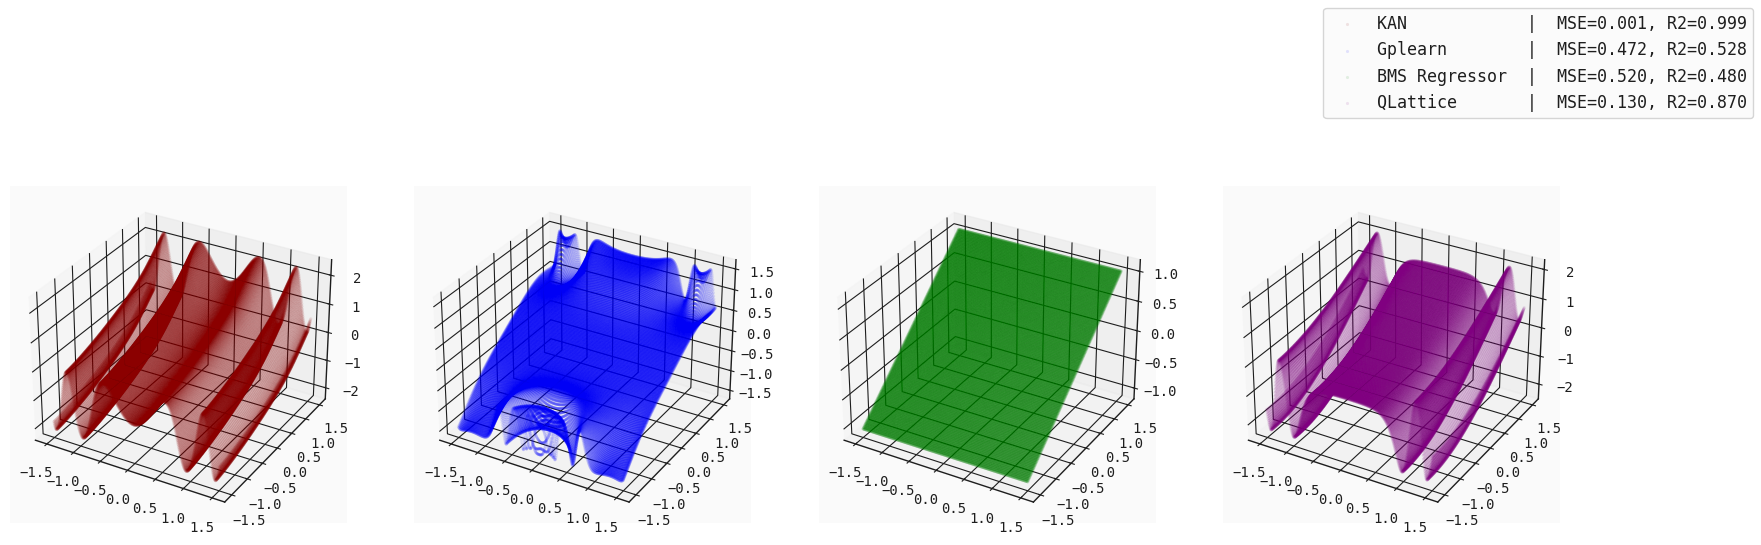

In [30]:
Xs2 = torch.cartesian_prod(torch.linspace(-1.5, 1.5, 500), torch.linspace(-1.5, 1.5, 150))
with torch.no_grad():
    kan_pred = kan_model(Xs)[:, 0], kan_model(Xs2)[:, 0]
    genetic_pred = genetic_model.predict(Xs), genetic_model.predict(Xs2)
    bms_pred = bms_model.predict(Xs)[:, 0], bms_model.predict(Xs2)[:, 0]
    qlattice_pred = qlattice_models[0].predict(pd.DataFrame({
        'x1': Xs[:, 0].flatten(),
        'x2': Xs[:, 1].flatten(),
    })), qlattice_models[0].predict(pd.DataFrame({
        'x1': Xs2[:, 0].flatten(),
        'x2': Xs2[:, 1].flatten(),
    }))

fig = plt.figure(figsize=(20, 7))
models = [('KAN', kan_pred, fig.add_subplot(141, projection='3d'), 'darkred'),
          ('Gplearn', genetic_pred, fig.add_subplot(142, projection='3d'), 'blue'),
          ('BMS Regressor', bms_pred, fig.add_subplot(143, projection='3d'), 'green'),
          ('QLattice', qlattice_pred, fig.add_subplot(144, projection='3d'), 'purple')
          ]
handles = []
for pred in models:
    mse, r2 = mean_squared_error(Ys, pred[1][0]), r2_score(Ys, pred[1][0])
    handles.append(pred[2].scatter(Xs2[:, 0], Xs2[:, 1], pred[1][1],
                                   label=f'{pred[0]}{" " * (max(map(lambda x: len(x[0]), models)) - len(pred[0]))}  |  MSE={mse:.3f}, R2={r2:.3f}',
                                   alpha=0.1, c=pred[3], marker='.', linewidths=0.01))
fig.legend(handles, map(lambda x: x.get_label(), handles),
           prop=font_manager.FontProperties(family='monospace', size=12))